# 06 — Advanced Features: Vegetation Indices + Phenology

**Goal:** Build the extended per-pixel feature set that captures *what makes
a pixel viticulture-suitable*. This is the single highest-leverage technique
in the strategy (see `00_strategy.ipynb` Tier A).

**Why this matters:** Raw band reflectance ignores known agronomic relationships.
Vegetation indices (NDVI, NDRE, etc.) compress 2 bands into one diagnostic
feature. Phenological metrics (peak day, integrated NDVI) summarise a 34-step
time series into 6–10 numbers that encode *how* vegetation grows over the year —
exactly the signal that distinguishes vineyards from other agriculture.

**Sentinel-2 band map for `m-sakka/agripotential`** (10 bands):

| Index | Name | Wavelength | Use |
|---|---|---|---|
| 0 | B1 | 443 nm | Coastal aerosol |
| 1 | B2 | 490 nm | Blue |
| 2 | B3 | 560 nm | Green |
| 3 | B4 | 665 nm | Red |
| 4 | B5 | 705 nm | Red Edge 1 |
| 5 | B6 | 740 nm | Red Edge 2 |
| 6 | B7 | 783 nm | Red Edge 3 |
| 7 | B8 | 842 nm | NIR |
| 8 | B8A | 865 nm | Narrow NIR |
| 9 | B9 | 945 nm | Water vapour |

**Indices we compute** (B11/B12 SWIR not available, so we skip Gao-NDWI):

| Index | Formula | Captures |
|---|---|---|
| NDVI | (B8 − B4) / (B8 + B4) | Vegetation vigour |
| NDRE | (B8 − B5) / (B8 + B5) | Chlorophyll, less saturated than NDVI |
| GCVI | (B8 / B3) − 1 | Chlorophyll content (linear) |
| EVI | 2.5·(B8−B4)/(B8 + 6·B4 − 7.5·B2 + 1) | Vegetation, atmosphere-corrected |
| SAVI | 1.5·(B8−B4)/(B8+B4+0.5) | Vegetation in sparse canopy |
| MSAVI | 0.5·(2·B8+1 − √((2·B8+1)² − 8·(B8−B4))) | Vegetation, soil-adjusted |
| NDWI(McFeeters) | (B3 − B8) / (B3 + B8) | Water bodies / saturated soil |
| PRI proxy | (B3 − B2) / (B3 + B2) | Photosynthetic activity, water stress |
| RE-NDVI | (B7 − B5) / (B7 + B5) | Red-edge vegetation index |

## 0. Setup

In [1]:
# !pip install -q rasterio scipy tqdm pillow

import csv
import json
import os
from pathlib import Path
from urllib.parse import urljoin
from urllib.request import urlopen

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ── REPO ROOT — works whether JupyterLab cwd is project root or notebooks/ ──
_cwd = Path(os.getcwd())
REPO_ROOT = _cwd if (_cwd / "scripts").exists() else _cwd.parent

# ── CONFIG ────────────────────────────────────────────────────────────────────
DATA_DIR     = None    # set to local path if data is downloaded
LABEL_NAME   = "viticulture"
HF_BASE      = "https://huggingface.co/datasets/m-sakka/agripotential/resolve/main/"
FEATURES_DIR = REPO_ROOT / "results" / "subtask1" / "features"
OUT_DIR      = REPO_ROOT / "results" / "subtask1" / "features_eda"
for d in [FEATURES_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Reflectance scale: Sentinel-2 L2A is uint16 with scale factor 0.0001.
# We divide by SCALE to get reflectance in [0, 1].
REFLECTANCE_SCALE = 10000.0

CLASS_NAMES  = ["Very Low", "Low", "Medium", "High", "Very High", "Unknown"]
CLASS_COLORS = ["#d73027", "#fc8d59", "#fee08b", "#91cf60", "#1a9850", "#808080"]

print(f"Repo root: {REPO_ROOT}")
print(f"Features cache: {FEATURES_DIR}")

Repo root: /workspace/ai4agri
Features cache: /workspace/ai4agri/results/subtask1/features


## 1. Metadata loader

In [2]:
import rasterio
from rasterio.windows import Window
import pandas as pd

def ref(name):
    return str(Path(DATA_DIR) / name) if DATA_DIR else urljoin(HF_BASE, name)

def csv_rows(name):
    r = ref(name)
    if r.startswith("http"):
        with urlopen(r, timeout=60) as h:
            lines = [l.decode() for l in h]
    else:
        lines = Path(r).read_text().splitlines()
    return list(csv.DictReader(lines))

metadata   = csv_rows("metadata.csv")
train_rows = csv_rows("train.csv")
val_rows   = csv_rows("val.csv")
test_rows  = csv_rows("test.csv")

meta_df = pd.DataFrame(metadata)
meta_df["date"] = pd.to_datetime(meta_df[["year","month","day"]].astype(int))
meta_df = meta_df.sort_values("date").reset_index(drop=True)
sentinel_files = list(meta_df["filename"])
n_times = len(sentinel_files)
n_bands = 10
label_ref = ref(f"{LABEL_NAME}.tif")

# Day-of-year for each timeframe — needed for phenology
doy = np.array([d.dayofyear for d in meta_df["date"]], dtype=np.float32)
print(f"Timeframes: {n_times}, DOY range: {int(doy.min())} → {int(doy.max())}")

Timeframes: 34, DOY range: 3 → 363


## 2. Vegetation index functions

In [3]:
def compute_indices(stack):
    """
    Compute vegetation indices from a (T, B, H, W) reflectance stack in [0, 1].
    Returns (T, n_indices, H, W) array.
    Index order: NDVI, NDRE, GCVI, EVI, SAVI, MSAVI, NDWI, PRI, RE_NDVI.
    """
    EPS = 1e-6
    B2 = stack[:, 1]; B3 = stack[:, 2]; B4 = stack[:, 3]
    B5 = stack[:, 4]; B7 = stack[:, 6]; B8 = stack[:, 7]

    NDVI    = (B8 - B4) / (B8 + B4 + EPS)
    NDRE    = (B8 - B5) / (B8 + B5 + EPS)
    GCVI    = (B8 / (B3 + EPS)) - 1.0
    EVI     = 2.5 * (B8 - B4) / (B8 + 6.0*B4 - 7.5*B2 + 1.0 + EPS)
    SAVI    = 1.5 * (B8 - B4) / (B8 + B4 + 0.5)
    msavi_arg = (2.0*B8 + 1.0)**2 - 8.0*(B8 - B4)
    MSAVI   = 0.5 * (2.0*B8 + 1.0 - np.sqrt(np.clip(msavi_arg, 0, None)))
    NDWI_M  = (B3 - B8) / (B3 + B8 + EPS)        # McFeeters water index
    PRI     = (B3 - B2) / (B3 + B2 + EPS)        # photosynthetic activity proxy
    RE_NDVI = (B7 - B5) / (B7 + B5 + EPS)

    return np.stack([NDVI, NDRE, GCVI, EVI, SAVI, MSAVI, NDWI_M, PRI, RE_NDVI], axis=1)

INDEX_NAMES = ["NDVI", "NDRE", "GCVI", "EVI", "SAVI", "MSAVI", "NDWI", "PRI", "RE_NDVI"]
N_INDICES = len(INDEX_NAMES)

# Self-test on synthetic data
test_stack = np.random.uniform(0.05, 0.5, size=(2, 10, 4, 4)).astype(np.float32)
out = compute_indices(test_stack)
assert out.shape == (2, N_INDICES, 4, 4), f"Bad shape: {out.shape}"
assert np.all(np.isfinite(out)), "Non-finite values in indices"
print(f"Indices: {INDEX_NAMES}")
print(f"Shape on synthetic input: {out.shape}")

Indices: ['NDVI', 'NDRE', 'GCVI', 'EVI', 'SAVI', 'MSAVI', 'NDWI', 'PRI', 'RE_NDVI']
Shape on synthetic input: (2, 9, 4, 4)


## 3. Phenology functions

In [4]:
from scipy.signal import savgol_filter


def smooth_time_series(values, window=7, polyorder=2):
    """Savitzky-Golay smoothing along axis 0 (time). Removes cloud spikes."""
    if values.shape[0] < window:
        return values
    return savgol_filter(values, window_length=window, polyorder=polyorder, axis=0, mode="nearest")


def phenology_features(ndvi_t, doy):
    """
    Compute pixel-wise phenology features from NDVI time series.
    
    Args:
        ndvi_t: (T, H, W) NDVI values (smoothed recommended)
        doy:    (T,) day-of-year for each timeframe
    
    Returns:
        (n_features, H, W) where features are:
          0: peak NDVI value
          1: DOY of peak (normalised /366)
          2: trough NDVI value
          3: amplitude (peak - trough)
          4: integrated NDVI (sum, normalised /T)
          5: green-up rate (mean positive derivative)
          6: senescence rate (mean negative derivative)
          7: growing-season length (count of timeframes with NDVI > 0.3, normalised /T)
          8: NDVI std across time
          9: linear-trend slope across the year
    """
    T, H, W = ndvi_t.shape
    peak = ndvi_t.max(axis=0)
    peak_idx = ndvi_t.argmax(axis=0)
    peak_doy = doy[peak_idx] / 366.0
    trough = ndvi_t.min(axis=0)
    amplitude = peak - trough
    integrated = ndvi_t.mean(axis=0)
    deriv = np.diff(ndvi_t, axis=0)
    pos_deriv = np.where(deriv > 0, deriv, 0).mean(axis=0)
    neg_deriv = np.where(deriv < 0, deriv, 0).mean(axis=0)
    growing_season = (ndvi_t > 0.3).mean(axis=0)
    std = ndvi_t.std(axis=0)
    # Linear trend (slope) — normalise time axis to [0, 1]
    t_norm = np.linspace(0, 1, T).reshape(-1, 1, 1)
    t_mean = t_norm.mean()
    ndvi_mean = ndvi_t.mean(axis=0, keepdims=True)
    slope_num = ((t_norm - t_mean) * (ndvi_t - ndvi_mean)).sum(axis=0)
    slope_den = ((t_norm - t_mean) ** 2).sum() + 1e-9
    slope = slope_num / slope_den

    return np.stack([peak, peak_doy, trough, amplitude, integrated,
                     pos_deriv, neg_deriv, growing_season, std, slope], axis=0).astype(np.float32)

PHENOLOGY_NAMES = ["peak", "peak_doy", "trough", "amplitude", "integrated",
                   "green_up", "senescence", "gs_length", "std", "slope"]
N_PHENOLOGY = len(PHENOLOGY_NAMES)
print(f"Phenology features: {PHENOLOGY_NAMES}")

Phenology features: ['peak', 'peak_doy', 'trough', 'amplitude', 'integrated', 'green_up', 'senescence', 'gs_length', 'std', 'slope']


## 4. Fourier (harmonic) features

In [5]:
def harmonic_features(ndvi_t, n_harmonics=2):
    """
    First N harmonics of NDVI time series capture annual seasonality compactly.
    Returns (1 + 2*N, H, W) — DC component + (cos, sin) for each harmonic.
    For T=34 timeframes spanning roughly 2 years, harmonic 1 = annual cycle.
    """
    T, H, W = ndvi_t.shape
    fft = np.fft.rfft(ndvi_t, axis=0)  # (T//2+1, H, W) complex
    feats = [fft[0].real / T]  # DC
    for k in range(1, n_harmonics + 1):
        if k < fft.shape[0]:
            feats.append(fft[k].real * 2 / T)
            feats.append(fft[k].imag * 2 / T)
        else:
            feats.append(np.zeros((H, W), dtype=np.float32))
            feats.append(np.zeros((H, W), dtype=np.float32))
    return np.stack(feats, axis=0).astype(np.float32)

HARMONIC_NAMES = ["H_DC", "H1_cos", "H1_sin", "H2_cos", "H2_sin"]
N_HARMONICS = len(HARMONIC_NAMES)
print(f"Harmonic features: {HARMONIC_NAMES}")

Harmonic features: ['H_DC', 'H1_cos', 'H1_sin', 'H2_cos', 'H2_sin']


## 5. Demo on one patch (visual sanity check)

In [6]:
def load_stack(row_idx, col_idx, patch_size):
    """Returns (T, B, H, W) reflectance stack in [0, 1]."""
    win = Window(col_idx, row_idx, patch_size, patch_size)
    frames = []
    for fname in sentinel_files:
        with rasterio.open(ref(fname)) as src:
            arr = src.read(window=win).astype(np.float32) / REFLECTANCE_SCALE
        frames.append(arr)
    return np.stack(frames, axis=0)  # (T, B, H, W)


patch = train_rows[0]
r, c, ps = int(patch["row"]), int(patch["col"]), int(patch["patch_size"])
print(f"Demo patch_id: {patch['patch_id']} at row={r}, col={c}, size={ps}")
stack = load_stack(r, c, ps)
print(f"Reflectance range: [{stack.min():.3f}, {stack.max():.3f}]")

indices = compute_indices(stack)  # (T, n_idx, H, W)
ndvi_t = indices[:, 0]              # (T, H, W)
ndvi_smooth = smooth_time_series(ndvi_t, window=7, polyorder=2)
phen = phenology_features(ndvi_smooth, doy)
harm = harmonic_features(ndvi_smooth, n_harmonics=2)
print(f"Indices shape: {indices.shape}")
print(f"Phenology shape: {phen.shape}")
print(f"Harmonics shape: {harm.shape}")

Demo patch_id: 7296_14720 at row=7296, col=14720, size=128
Reflectance range: [0.004, 2.296]
Indices shape: (34, 9, 128, 128)
Phenology shape: (10, 128, 128)
Harmonics shape: (5, 128, 128)


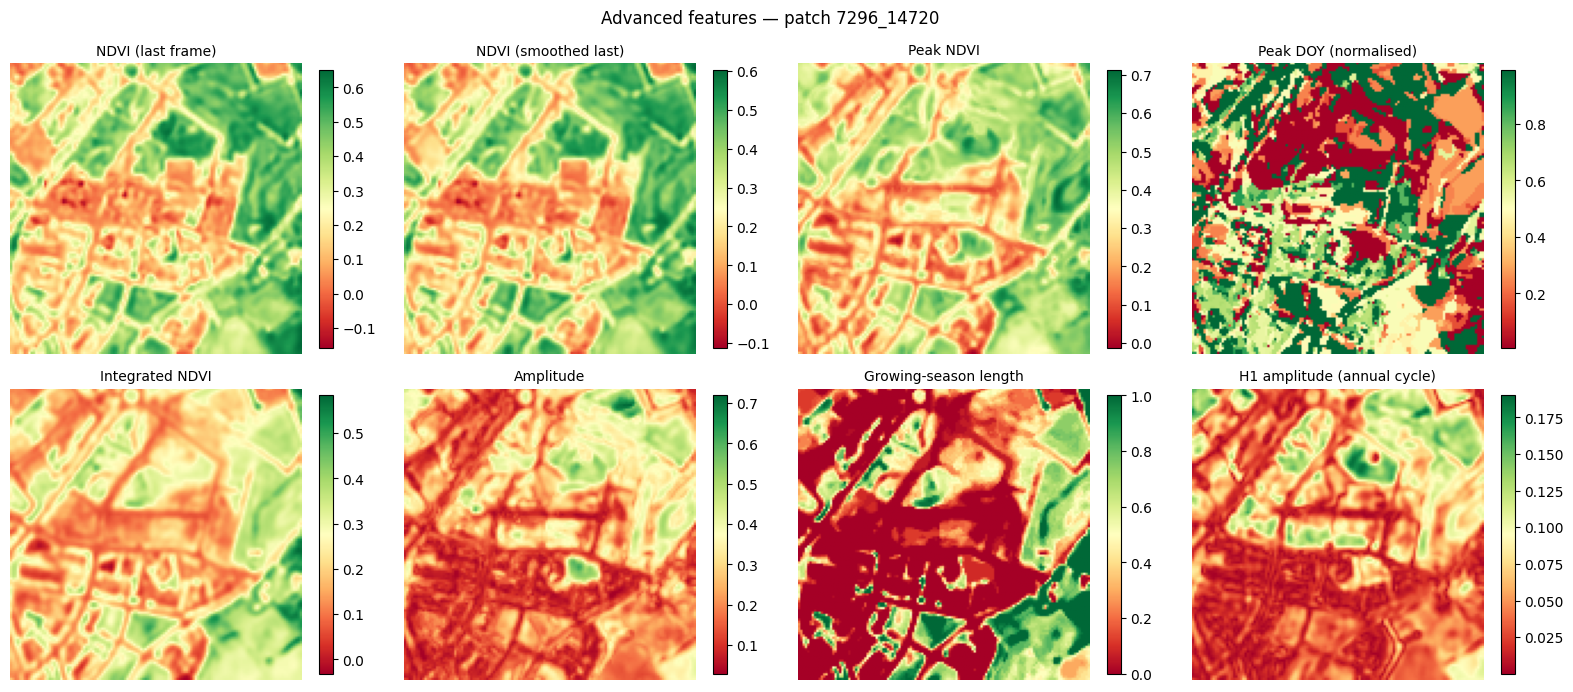

Saved → /workspace/ai4agri/results/subtask1/features_eda/demo_patch_features.png


In [7]:
# Visualise the four most diagnostic feature maps for the demo patch
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, (name, m) in zip(axes.ravel(), [
    ("NDVI (last frame)", ndvi_t[-1]),
    ("NDVI (smoothed last)", ndvi_smooth[-1]),
    ("Peak NDVI", phen[0]),
    ("Peak DOY (normalised)", phen[1]),
    ("Integrated NDVI", phen[4]),
    ("Amplitude", phen[3]),
    ("Growing-season length", phen[7]),
    ("H1 amplitude (annual cycle)", np.sqrt(harm[1]**2 + harm[2]**2)),
]):
    im = ax.imshow(m, cmap="RdYlGn")
    ax.set_title(name, fontsize=10)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.04)

plt.suptitle(f"Advanced features — patch {patch['patch_id']}", fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / "demo_patch_features.png", dpi=120)
plt.show()
print(f"Saved → {OUT_DIR}/demo_patch_features.png")

## 6. Per-class phenology profile (pre-training intuition)

Profile sampling:   0%|          | 0/700 [00:00<?, ?it/s]

Cached profile sample → /workspace/ai4agri/results/subtask1/features_eda/class_ndvi_profiles_sample.npz
Scanned label windows: 83
Profile patches by scored class: {3: 8, 0: 8, 2: 8, 1: 8, 4: 8}


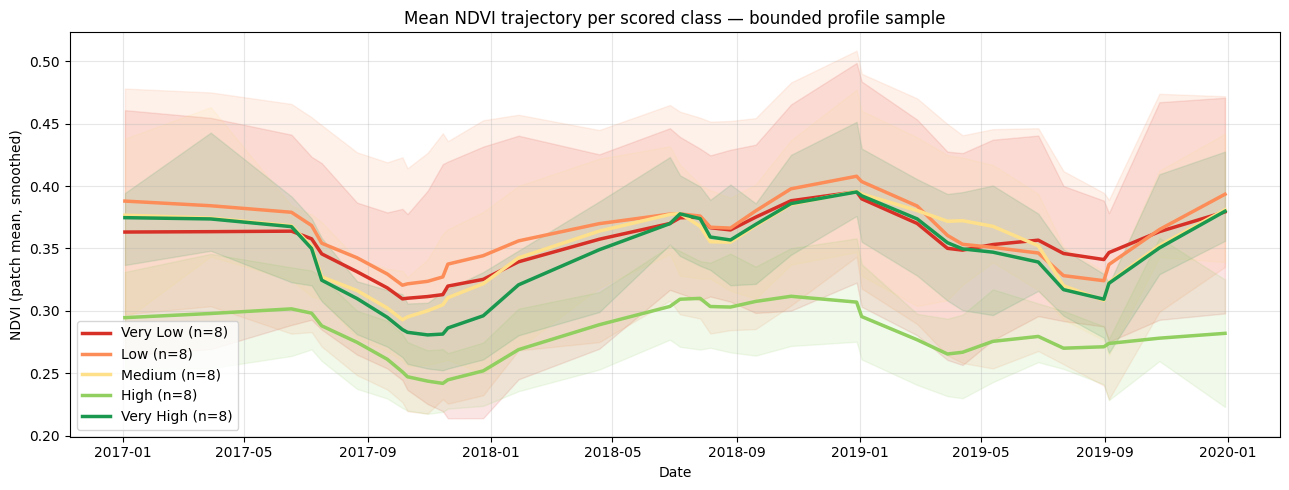

Saved → /workspace/ai4agri/results/subtask1/features_eda/class_ndvi_profiles.png


In [8]:
# Compare mean smoothed-NDVI time series across scored classes 0..4.
# This cell is intentionally bounded: remote raster window reads are slow, and
# scanning all 6,329 train patches can take more than an hour from Jupyter.
from collections import Counter

PROFILE_PATCHES_PER_CLASS = 8      # raise to 20-30 only when data is local
PROFILE_SCAN_LIMIT = 700           # max label windows to inspect
PROFILE_MIN_VALID_PIXELS = 512     # skip mostly nodata/boundary patches
PROFILE_RANDOM_SEED = 42
PROFILE_CACHE = OUT_DIR / "class_ndvi_profiles_sample.npz"
FORCE_PROFILE_REBUILD = False


def dominant_scored_class(labels):
    counts = np.bincount(labels[(labels >= 0) & (labels <= 4)].astype(np.uint8), minlength=5)
    if int(counts.sum()) < PROFILE_MIN_VALID_PIXELS:
        return None
    return int(counts.argmax())


def load_ndvi_series(row_idx, col_idx, patch_size):
    """Read only red and NIR windows, then return mean NDVI per timeframe."""
    win = Window(col_idx, row_idx, patch_size, patch_size)
    means = []
    for f in sentinel_files:
        with rasterio.open(ref(f)) as src:
            red, nir = src.read([4, 8], window=win).astype(np.float32) / REFLECTANCE_SCALE
        red[(red < 0) | (red > 1.5)] = np.nan
        nir[(nir < 0) | (nir > 1.5)] = np.nan
        ndvi = (nir - red) / (nir + red + 1e-6)
        means.append(float(np.nanmean(ndvi)))
    return np.asarray(means, dtype=np.float32)


if PROFILE_CACHE.exists() and not FORCE_PROFILE_REBUILD:
    cached = np.load(PROFILE_CACHE, allow_pickle=True)
    class_ndvi = {int(k): list(v) for k, v in cached["class_ndvi"].item().items()}
    class_counts = Counter({int(k): len(v) for k, v in class_ndvi.items()})
    scanned = int(cached.get("scanned", 0))
    print(f"Loaded cached profile sample from {PROFILE_CACHE}")
else:
    rng = np.random.default_rng(PROFILE_RANDOM_SEED)
    scan_rows = list(train_rows)
    rng.shuffle(scan_rows)
    scan_rows = scan_rows[:min(PROFILE_SCAN_LIMIT, len(scan_rows))]

    class_ndvi = {c: [] for c in range(5)}
    class_counts = Counter()
    scanned = 0

    with rasterio.open(label_ref) as lsrc:
        for patch in tqdm(scan_rows, desc="Profile sampling", total=len(scan_rows)):
            if all(class_counts.get(c, 0) >= PROFILE_PATCHES_PER_CLASS for c in range(5)):
                break
            scanned += 1
            r, c, ps = int(patch["row"]), int(patch["col"]), int(patch["patch_size"])
            lbl = lsrc.read(1, window=Window(c, r, ps, ps)).ravel()
            cls = dominant_scored_class(lbl)
            if cls is None or class_counts[cls] >= PROFILE_PATCHES_PER_CLASS:
                continue
            class_counts[cls] += 1
            class_ndvi[cls].append(load_ndvi_series(r, c, ps))

    np.savez_compressed(
        PROFILE_CACHE,
        class_ndvi={k: np.asarray(v, dtype=np.float32) for k, v in class_ndvi.items()},
        scanned=scanned,
        patches_per_class=PROFILE_PATCHES_PER_CLASS,
        scan_limit=PROFILE_SCAN_LIMIT,
    )
    print(f"Cached profile sample → {PROFILE_CACHE}")

print("Scanned label windows:", scanned)
print("Profile patches by scored class:", dict(class_counts))
missing = [CLASS_NAMES[c] for c in range(5) if class_counts.get(c, 0) == 0]
if missing:
    print("Missing classes in bounded sample:", missing)
    print("Increase PROFILE_SCAN_LIMIT or PROFILE_PATCHES_PER_CLASS if you need denser profiles.")

fig, ax = plt.subplots(figsize=(13, 5))
for cls in range(5):
    if not class_ndvi[cls]:
        continue
    arr = np.stack(class_ndvi[cls])  # (n_patches, T)
    mean = np.nanmean(arr, axis=0)
    std = np.nanstd(arr, axis=0)
    smooth_mean = smooth_time_series(mean[:, None, None], 7, 2).ravel()
    ax.plot(
        meta_df["date"],
        smooth_mean,
        label=f"{CLASS_NAMES[cls]} (n={class_counts[cls]})",
        color=CLASS_COLORS[cls],
        linewidth=2.5,
    )
    ax.fill_between(meta_df["date"], mean - std, mean + std, color=CLASS_COLORS[cls], alpha=0.12)
ax.set_ylabel("NDVI (patch mean, smoothed)")
ax.set_xlabel("Date")
ax.set_title("Mean NDVI trajectory per scored class — bounded profile sample")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "class_ndvi_profiles.png", dpi=120)
plt.show()
print(f"Saved → {OUT_DIR}/class_ndvi_profiles.png")


## 7. Cache extended features for downstream notebooks

We cache **patch-level** feature maps (one `.npz` per patch) so that NB2,
NB3, NB7, NB9 can load them without recomputing. Total storage estimate:

- 6,329 train + 781 val + 800 test = 7,910 patches
- Per patch: (n_indices × T) + n_phenology + n_harmonics channels at 128×128 float32
  ≈ (9·34 + 10 + 5) × 128² × 4 bytes ≈ 21 MB/patch
- Total ≈ 165 GB — too large for the 450 GB volume after raw data

**Decision:** cache only **summary** statistics per patch (per-band temporal
stats + per-pixel phenology + per-pixel harmonics). That's ~1.5 MB/patch =
~12 GB total. Compute indices on-the-fly during training; phenology features
are the slow part to recompute.

Set `CACHE_PHENOLOGY = True` to enable. Skip if disk is tight; the feature
functions above are cheap enough to inline.

In [11]:
CACHE_PHENOLOGY = True
CACHE_LIMIT     = 0     # 0 = process all patches; set small int to test pipeline

def cache_patch_features(patch, split):
    """Compute and cache phenology + harmonics for a single patch."""
    patch_id = str(patch["patch_id"])
    out = FEATURES_DIR / split / f"{patch_id}.npz"
    if out.exists():
        return False  # already cached
    out.parent.mkdir(parents=True, exist_ok=True)

    r, c, ps = int(patch["row"]), int(patch["col"]), int(patch["patch_size"])
    stack = load_stack(r, c, ps)
    indices = compute_indices(stack)         # (T, n_idx, H, W)
    ndvi_t  = indices[:, 0]                   # NDVI through time
    ndvi_s  = smooth_time_series(ndvi_t, 7, 2)
    phen    = phenology_features(ndvi_s, doy)  # (n_phen, H, W)
    harm    = harmonic_features(ndvi_s, 2)      # (n_harm, H, W)

    # Per-band per-time mean/std summaries (cheaper than full T×B×H×W)
    pix = stack.transpose(2, 3, 0, 1)  # (H, W, T, B)
    band_mean = pix.mean(axis=2).transpose(2, 0, 1)  # (B, H, W)
    band_std  = pix.std(axis=2).transpose(2, 0, 1)
    np.savez_compressed(out,
                        phenology=phen.astype(np.float32),
                        harmonics=harm.astype(np.float32),
                        band_mean=band_mean.astype(np.float32),
                        band_std=band_std.astype(np.float32))
    return True

if CACHE_PHENOLOGY:
    for split, rows in [("train", train_rows), ("val", val_rows), ("test", test_rows)]:
        rows_to_do = rows[:CACHE_LIMIT] if CACHE_LIMIT > 0 else rows
        n_done = 0
        for p in tqdm(rows_to_do, desc=f"Caching {split}"):
            n_done += int(cache_patch_features(p, split))
        print(f"  {split}: {n_done} new caches written")
else:
    print("CACHE_PHENOLOGY = False — recompute on-the-fly during training.")

Caching train:   0%|          | 0/6329 [00:00<?, ?it/s]

  train: 0 new caches written


Caching val:   0%|          | 0/781 [00:00<?, ?it/s]

  val: 0 new caches written


Caching test:   0%|          | 0/800 [00:00<?, ?it/s]

  test: 0 new caches written


## 8. Save a feature manifest for downstream notebooks

In [12]:
manifest = {
    "reflectance_scale": REFLECTANCE_SCALE,
    "index_names": INDEX_NAMES,
    "phenology_names": PHENOLOGY_NAMES,
    "harmonic_names": HARMONIC_NAMES,
    "sav_gol_window": 7,
    "sav_gol_polyorder": 2,
    "cache_dir": str(FEATURES_DIR),
    "cached": CACHE_PHENOLOGY,
    "n_timeframes": n_times,
    "timeframe_doy": doy.tolist(),
    "label_name": LABEL_NAME,
}
(FEATURES_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2))
print("Saved manifest.json")
print(json.dumps({k: v for k, v in manifest.items() if k != "timeframe_doy"}, indent=2))

Saved manifest.json
{
  "reflectance_scale": 10000.0,
  "index_names": [
    "NDVI",
    "NDRE",
    "GCVI",
    "EVI",
    "SAVI",
    "MSAVI",
    "NDWI",
    "PRI",
    "RE_NDVI"
  ],
  "phenology_names": [
    "peak",
    "peak_doy",
    "trough",
    "amplitude",
    "integrated",
    "green_up",
    "senescence",
    "gs_length",
    "std",
    "slope"
  ],
  "harmonic_names": [
    "H_DC",
    "H1_cos",
    "H1_sin",
    "H2_cos",
    "H2_sin"
  ],
  "sav_gol_window": 7,
  "sav_gol_polyorder": 2,
  "cache_dir": "/workspace/ai4agri/results/subtask1/features",
  "cached": true,
  "n_timeframes": 34,
  "label_name": "viticulture"
}


## 9. HITL handoff

Review `class_ndvi_profiles.png` carefully:

1. **Is there clear vertical separation between class curves?** If yes,
   integrated NDVI alone will be a top-3 feature. If no, the signal is mostly
   in spatial context (good for U-Net) or in non-NDVI bands.
2. **At which dates do classes diverge most?** These timeframes deserve higher
   weight — list them in `feature_priorities` for NB2.
3. **Is class 4 (Very High) above or below class 0 (Very Low)?** Higher NDVI
   does not always mean higher viticulture potential — vineyards have
   *moderate* canopy compared to corn. If class 4 NDVI is *lower* than class 0
   in summer, that's the diagnostic signature; flag it for the report.

After review, NB2 (`02_pixel_baseline_subtask1.ipynb`) extends its feature
extractor to call `compute_indices` and `phenology_features` from this notebook
(import as a module, or copy the functions into the cell). Expected gain:
**+5–8% Accuracy±1** on the val set vs. raw-band baseline.